<a href="https://colab.research.google.com/github/Naman1232/ML-PROJECTS/blob/main/Time_Series_Forecasting_using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
from google.colab import files
import io
uploaded = files.upload()

Saving AirPassengers.csv to AirPassengers.csv


In [3]:
dataframe = pd.read_csv(io.BytesIO(uploaded['AirPassengers.csv']), usecols=[1])
print(dataframe.head())

   #Passengers
0          112
1          118
2          132
3          129
4          121


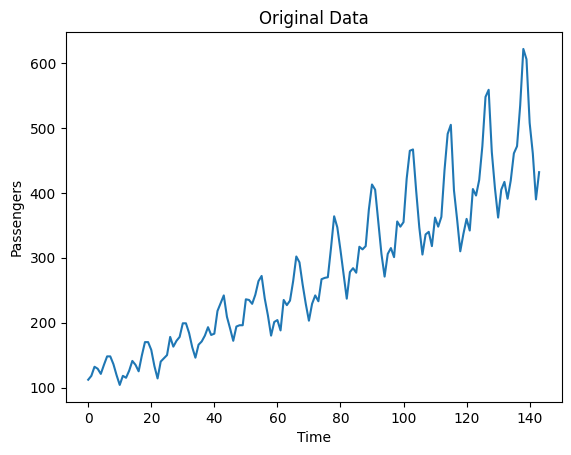

In [4]:
plt.plot(dataframe)
plt.title('Original Data')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.show()


In [5]:
dataset = dataframe.values.astype('float32')
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

In [6]:
train_size = int(len(dataset) * 0.66)
train, test = dataset[:train_size], dataset[train_size:]

In [7]:
def to_sequences(dataset, seq_size=1):
    x, y = [], []
    for i in range(len(dataset) - seq_size - 1):
        x.append(dataset[i:(i + seq_size), 0])
        y.append(dataset[i + seq_size, 0])
    return np.array(x), np.array(y)

seq_size = 10
trainX, trainY = to_sequences(train, seq_size)
testX, testY = to_sequences(test, seq_size)

print("Shape of training set:", trainX.shape)
print("Shape of test set:", testX.shape)

Shape of training set: (84, 10)
Shape of test set: (38, 10)


In [8]:
# Reshape for LSTM input [samples, time steps, features]
trainX = trainX.reshape(trainX.shape[0], trainX.shape[1], 1)
testX = testX.reshape(testX.shape[0], testX.shape[1], 1)

In [28]:
model = Sequential()
model.add(LSTM(64, return_sequences=False, input_shape=(seq_size, 1)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
model.summary()

# Train model
model.fit(trainX, trainY, validation_data=(testX, testY), epochs=100, verbose=2)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
3/3 - 2s - 664ms/step - loss: 0.0489 - mae: 0.1874 - val_loss: 0.1817 - val_mae: 0.4007
Epoch 2/100
3/3 - 0s - 28ms/step - loss: 0.0239 - mae: 0.1214 - val_loss: 0.0831 - val_mae: 0.2510
Epoch 3/100
3/3 - 0s - 44ms/step - loss: 0.0093 - mae: 0.0704 - val_loss: 0.0289 - val_mae: 0.1232
Epoch 4/100
3/3 - 0s - 48ms/step - loss: 0.0055 - mae: 0.0614 - val_loss: 0.0198 - val_mae: 0.1194
Epoch 5/100
3/3 - 0s - 27ms/step - loss: 0.0084 - mae: 0.0801 - val_loss: 0.0205 - val_mae: 0.1227
Epoch 6/100
3/3 - 0s - 26ms/step - loss: 0.0071 - mae: 0.0728 - val_loss: 0.0195 - val_mae: 0.1116
Epoch 7/100
3/3 - 0s - 30ms/step - loss: 0.0052 - mae: 0.0590 - val_loss: 0.0265 - val_mae: 0.1179
Epoch 8/100
3/3 - 0s - 45ms/step - loss: 0.0049 - mae: 0.0524 - val_loss: 0.0320 - val_mae: 0.1308
Epoch 9/100
3/3 - 0s - 45ms/step - loss: 0.0053 - mae: 0.0532 - val_loss: 0.0301 - val_mae: 0.1263
Epoch 10/100
3/3 - 0s - 46ms/step - loss: 0.0050 - mae: 0.0521 - val_loss: 0.0242 - val_mae: 0.1139
Epoch 11

In [29]:
testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)
testY_inverse = scaler.inverse_transform([testY])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


In [30]:
test_rmse = math.sqrt(mean_squared_error(testY_inverse[0], testPredict[:, 0]))
test_mae = mean_absolute_error(testY_inverse[0], testPredict[:, 0])
test_r2 = r2_score(testY_inverse[0], testPredict[:, 0])

def regression_accuracy(y_true, y_pred):
    return 100 - (np.mean(np.abs(y_pred - y_true) / y_true) * 100)

test_acc = regression_accuracy(testY_inverse[0], testPredict[:, 0])
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test Accuracy (approx): {test_acc:.2f}%")

Test RMSE: 50.26
Test MAE: 42.95
Test R² Score: 0.6021
Test Accuracy (approx): 89.27%


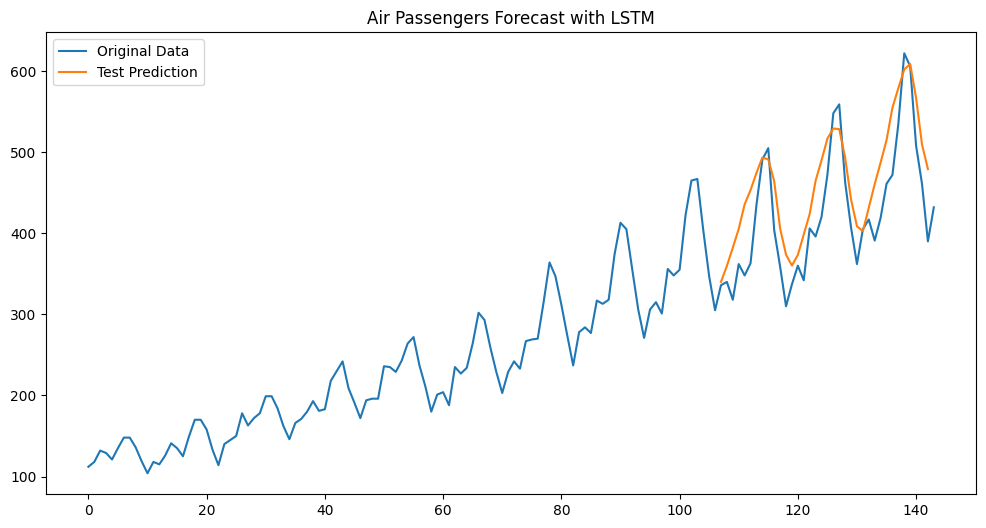

In [31]:
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainX) + (seq_size * 2) + 1:len(dataset) - 1, :] = testPredict

plt.figure(figsize=(12, 6))
plt.plot(scaler.inverse_transform(dataset), label='Original Data')
plt.plot(testPredictPlot, label='Test Prediction')
plt.legend()
plt.title("Air Passengers Forecast with LSTM")
plt.show()

In [32]:
def predict_future(model, data, n_future, seq_size, scaler):
    future_predictions = []
    last_sequence = data[-seq_size:].reshape(1, seq_size, 1)
    for _ in range(n_future):
        pred = model.predict(last_sequence, verbose=0)
        future_predictions.append(pred[0, 0])
        last_sequence = np.append(last_sequence[:, 1:, :], [[[pred[0][0]]]], axis=1)
    future_predictions = np.array(future_predictions).reshape(-1, 1)
    return scaler.inverse_transform(future_predictions)

n_future = 24
future_preds = predict_future(model, dataset, n_future, seq_size, scaler)


In [33]:
last_date = pd.to_datetime('1949-01') + pd.DateOffset(months=len(dataset))
future_dates = pd.date_range(last_date, periods=n_future, freq='MS')
future_df = pd.DataFrame({'Month': future_dates, 'Predicted Passengers': future_preds.flatten().round()})
print(future_df)

        Month  Predicted Passengers
0  1961-01-01                 483.0
1  1961-02-01                 522.0
2  1961-03-01                 573.0
3  1961-04-01                 624.0
4  1961-05-01                 666.0
5  1961-06-01                 697.0
6  1961-07-01                 705.0
7  1961-08-01                 673.0
8  1961-09-01                 622.0
9  1961-10-01                 586.0
10 1961-11-01                 573.0
11 1961-12-01                 596.0
12 1962-01-01                 632.0
13 1962-02-01                 673.0
14 1962-03-01                 714.0
15 1962-04-01                 749.0
16 1962-05-01                 771.0
17 1962-06-01                 779.0
18 1962-07-01                 770.0
19 1962-08-01                 748.0
20 1962-09-01                 723.0
21 1962-10-01                 706.0
22 1962-11-01                 704.0
23 1962-12-01                 715.0


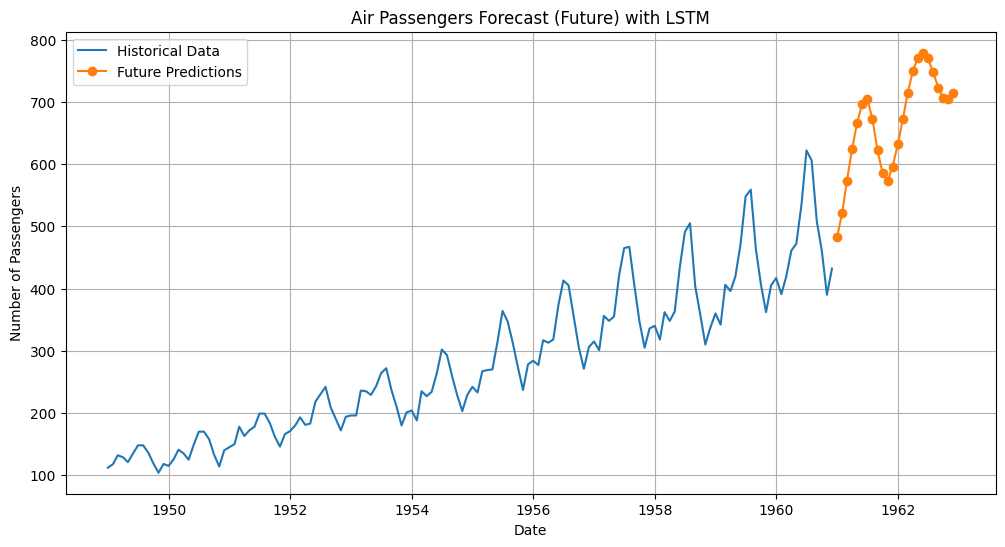

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(pd.date_range('1949-01', periods=len(dataset), freq='MS'), scaler.inverse_transform(dataset), label='Historical Data')
plt.plot(future_df['Month'], future_df['Predicted Passengers'], label='Future Predictions', marker='o')
plt.title('Air Passengers Forecast (Future) with LSTM')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()